<a href="https://colab.research.google.com/github/Nemosimes/NLP-Project/blob/MS1/MS1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nemosimes/NLP-Project/blob/MS1/MS1.ipynb)

# Milestone 1 — Arabic NLP: EDA, Normalization & Data Preparation

This notebook covers exploratory data analysis, text normalization, and data preparation for a corpus of **13 Arabic transcripts** and **3890 QA pairs** from the *الدحيح* YouTube channel.

In [ ]:
import zipfile

zip_file_path = '/content/project data.zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('.')

In [ ]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Load transcripts
transcripts_dir = '/content/Project Data/Transcripts'
transcripts = {}
for fname in os.listdir(transcripts_dir):
    if fname.endswith('.txt'):
        fpath = os.path.join(transcripts_dir, fname)
        with open(fpath, 'r', encoding='utf-8') as f:
            transcripts[fname.replace('.txt', '')] = f.read()

print(f'Loaded {len(transcripts)} transcripts')

# Load QA pairs
qa_dir = '/content/Project Data/QA'
qa_frames = []
for fname in os.listdir(qa_dir):
    if fname.endswith('.csv'):
        fpath = os.path.join(qa_dir, fname)
        df = pd.read_csv(fpath)
        qa_frames.append(df)

qa_df = pd.concat(qa_frames, ignore_index=True)
print(f'Loaded {len(qa_df)} QA pairs')
print(qa_df.columns.tolist())
qa_df.head()

Loaded 13 transcripts
Loaded 3890 QA pairs
['video_id', 'video_title', 'question_id', 'question', 'answer', 'difficulty']


,video_id,video_title,question_id,question,answer,difficulty
0,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q001,ماذا ورد في النص حول هذه الجزئية؟,والساموزين والسامو عليكم!,Easy
1,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q002,ما الجملة المذكورة في هذا الموضع؟,من كل مَن حرمه من حلم الساموراي...,Medium
2,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q003,كيف صيغت العبارة في النص؟,السلام عليكم ورحمة الله وبركاته،,Easy
3,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q004,ما الذي قيل في هذا السياق؟,"من برنامج ""الدحّيح""!",Medium
4,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q005,ما النص الحرفي المذكور هنا؟,خلّيني آخدك مش لمكان واحد،,Easy


# Exploratory Data Analysis
## Basic Statistics

In [ ]:
qa_df['question_len'] = qa_df['question'].astype(str).apply(lambda x: len(x.split()))
qa_df['answer_len'] = qa_df['answer'].astype(str).apply(lambda x: len(x.split()))
qa_df[['question_len', 'answer_len']].describe()

,question_len,answer_len
count,3890.000000,3890.000000
mean,6.084833,4.940617
std,1.372132,1.617219
min,3.000000,1.000000
25%,5.000000,4.000000
50%,6.000000,5.000000
75%,7.000000,6.000000
max,9.000000,10.000000


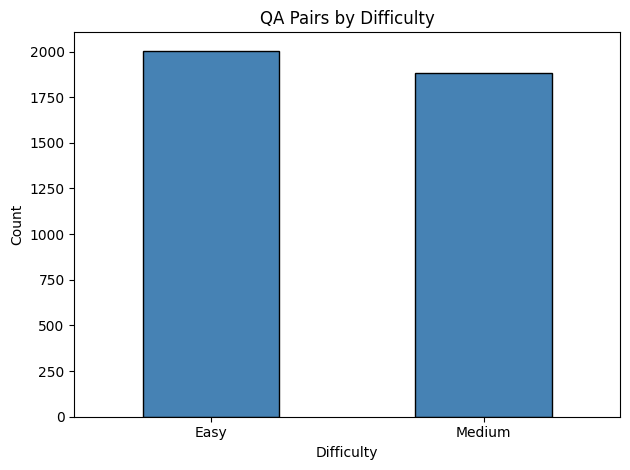

In [ ]:
if 'difficulty' in qa_df.columns:
    qa_df['difficulty'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('QA Pairs by Difficulty')
    plt.xlabel('Difficulty')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No difficulty column found')

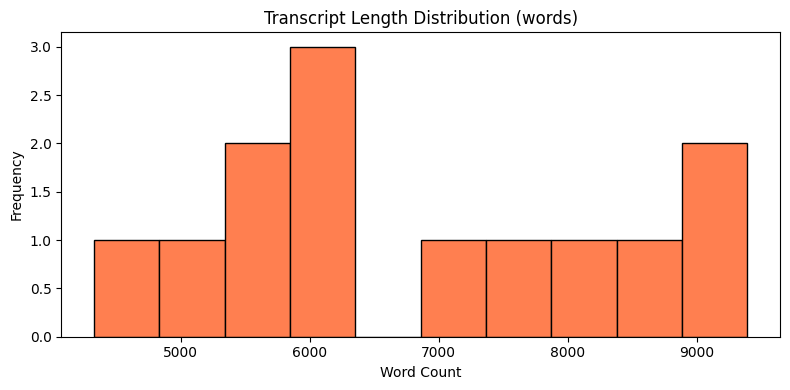

In [ ]:
transcript_lengths = [len(t.split()) for t in transcripts.values()]
plt.figure(figsize=(8, 4))
plt.hist(transcript_lengths, bins=10, color='coral', edgecolor='black')
plt.title('Transcript Length Distribution (words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Noise & Linguistic Features

In [ ]:
def contains_english(text):
    return bool(re.search(r'[A-Za-z]', str(text)))

qa_df['english_in_question'] = qa_df['question'].apply(contains_english)
print(qa_df['english_in_question'].value_counts())

english_in_question
False    3890
Name: count, dtype: int64


In [ ]:
timestamp_pattern = r'\d+\.\d+:'
for title, text in transcripts.items():
    count = len(re.findall(timestamp_pattern, text))
    print(f'{title}: {count} timestamps')

منابع النيل  الدحيح: 1065 timestamps
هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح: 717 timestamps
أعظم طائرة حربية  الدحيح: 761 timestamps
الأخطبوط  الدحيح: 784 timestamps
الساموراي  الدحيح: 662 timestamps
تاج محل  الدحيح: 547 timestamps
كيف تحولت روسيا إلى إمبراطورية؟  الدحيح: 1166 timestamps
جون كينيدي  الدحيح: 1125 timestamps
معركة ذي قار  الدحيح: 1006 timestamps
كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح: 757 timestamps
فيزياء و فلسفة الحركة  الدحيح: 955 timestamps
كيف تسيطر على عقول البشر؟  الدحيح: 908 timestamps
مصير الأرض و الشمس و كل شيء  الدحيح: 656 timestamps


In [ ]:
egyptian_words = [
    'ليه', 'انتو', 'بتاع', 'إيه', 'دا', 'دي', 'دول', 'بقى', 'مش', 'كدا',
    'كده', 'احنا', 'عشان', 'لما', 'دلوقتي', 'فيه', 'عايز', 'خالص', 'يعني',
    'ياه', 'بقا', 'ولا', 'هيبقى', 'هتبقى', 'بيعمل', 'بيقول', 'بيشوف',
    'هيجي', 'هيعمل', 'ممكن', 'حاجة', 'زي', 'كمان', 'برضه', 'بس', 'طب',
    'يا ابني'
]

def count_dialect(text):
    count = 0
    for word in egyptian_words:
        count += len(re.findall(r'\b' + re.escape(word) + r'\b', text))
    return count

total_dialect = 0
for title, text in transcripts.items():
    c = count_dialect(text)
    total_dialect += c
    print(f'{title}: {c}')
print(f'\nTotal dialect words: {total_dialect}')

منابع النيل  الدحيح: 342
هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح: 396
أعظم طائرة حربية  الدحيح: 454
الأخطبوط  الدحيح: 498
الساموراي  الدحيح: 291
تاج محل  الدحيح: 309
كيف تحولت روسيا إلى إمبراطورية؟  الدحيح: 539
جون كينيدي  الدحيح: 471
معركة ذي قار  الدحيح: 533
كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح: 355
فيزياء و فلسفة الحركة  الدحيح: 557
كيف تسيطر على عقول البشر؟  الدحيح: 452
مصير الأرض و الشمس و كل شيء  الدحيح: 369

Total dialect words: 5566


In [ ]:
narrative_markers = ['تخيل', 'طيب', 'خلينا', 'بص', 'فكر', 'تعالى', 'دلوقتي']

def count_narrative(text):
    counts = {}
    for marker in narrative_markers:
        counts[marker] = len(re.findall(re.escape(marker), text))
    return counts

all_text = ' '.join(transcripts.values())
marker_counts = count_narrative(all_text)
total_narrative = sum(marker_counts.values())
print(f'Total narrative marker occurrences: {total_narrative}')
for marker, count in marker_counts.items():
    print(f'  {marker}: {count}')

Total narrative marker occurrences: 431
  تخيل: 44
  طيب: 15
  خلينا: 1
  بص: 122
  فكر: 133
  تعالى: 25
  دلوقتي: 91


In [ ]:
named_entities = ['اينشتاين', 'نيوتن', 'داروين', 'تورنج', 'اديسون', 'ارسطو', 'افلاطون']

all_text = ' '.join(transcripts.values())
print('Named entity frequencies in all transcripts:')
for entity in named_entities:
    count = len(re.findall(re.escape(entity), all_text))
    print(f'  {entity}: {count}')

Named entity frequencies in all transcripts:
  اينشتاين: 0
  نيوتن: 3
  داروين: 1
  تورنج: 0
  اديسون: 0
  ارسطو: 0
  افلاطون: 0


## Vocabulary & Patterns

In [ ]:
all_text = ' '.join(transcripts.values())
all_words = all_text.split()
vocab = Counter(all_words)
print(f'Vocabulary size: {len(vocab)}')
print('Top 20 words:')
for word, count in vocab.most_common(20):
    print(f'  {word}: {count}')

Vocabulary size: 36776
Top 20 words:
  في: 1995
  يا: 1806
  عزيزي،: 1313
  من: 1292
  اللي: 1276
  ما: 1135
  إن: 916
  على: 885
  كان: 619
  دا: 472
  مش: 469
  هو: 429
  كل: 413
  عشان: 365
  زي: 341
  دي: 338
  انت: 296
  بس: 263
  كانت: 261
  كدا،: 250


In [ ]:
first_words = [str(q).split()[0] for q in qa_df['question'] if str(q).split()]
first_word_counts = Counter(first_words)
print('Top 10 question-starting words:')
for word, count in first_word_counts.most_common(10):
    print(f'  {word}: {count}')

Top 10 question-starting words:
  ما: 2390
  ماذا: 690
  كيف: 660
  في: 60
  لماذا: 30
  كم: 30
  أين: 30


In [ ]:
transcript_texts = list(transcripts.values())
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20, analyzer='word')
X = vectorizer.fit_transform(transcript_texts)
bigram_counts = X.toarray().sum(axis=0)
bigram_names = vectorizer.get_feature_names_out()
bigrams_sorted = sorted(zip(bigram_names, bigram_counts), key=lambda x: -x[1])
print('Top 20 bigrams:')
for bg, cnt in bigrams_sorted[:20]:
    print(f'  {bg}: {cnt}')

Top 20 bigrams:
  يا عزيزي: 1382
  أبو حميد: 183
  يا أبو: 143
  زي ما: 130
  إن هو: 120
  دا يا: 95
  عزيزي إن: 93
  ما فيش: 67
  هو اللي: 61
  إن انت: 60
  من غير: 60
  اللي كان: 59
  خل يني: 58
  لحد ما: 57
  إن ما: 56
  دي يا: 55
  ما كانش: 53
  مش بس: 52
  هنا يا: 51
  الف رس: 48


In [ ]:
if 'video_id' in qa_df.columns:
    multi = qa_df.groupby(['video_id', 'question'])['answer'].nunique()
    multi_count = (multi > 1).sum()
    print(f'Questions with multiple answers: {multi_count}')
else:
    print('video_id column not found; trying with available columns')
    print(qa_df.columns.tolist())

Questions with multiple answers: 55


## Advanced EDA

In [ ]:
ARABIC_WORD_RE = re.compile(r"[\u0600-\u06FF\u0750-\u077F]+")
TIMESTAMP_RE = re.compile(r"^\d+\.?\d*:\s*", re.MULTILINE)

rows = []
all_arabic_tokens = []
for title, text in transcripts.items():
    clean = TIMESTAMP_RE.sub('', text)
    tokens = ARABIC_WORD_RE.findall(clean)
    all_arabic_tokens.extend(tokens)
    unique_tokens = set(tokens)
    ttr = len(unique_tokens) / len(tokens) if tokens else 0
    freq = Counter(tokens)
    hapax = sum(1 for v in freq.values() if v == 1)
    rows.append({'Transcript': title, 'Tokens': len(tokens),
                 'Unique': len(unique_tokens),
                 'TTR': round(ttr, 3), 'Hapax': hapax})

stats_df = pd.DataFrame(rows)
print(stats_df.to_string(index=False))

vocab_freq = Counter(all_arabic_tokens)
hapax_total = sum(1 for v in vocab_freq.values() if v == 1)
print(f'\nTotal Arabic tokens: {len(all_arabic_tokens)}')
print(f'Vocabulary size: {len(vocab_freq)}')
print(f'Hapax legomena: {hapax_total} ({100*hapax_total/len(vocab_freq):.1f}% of vocab)')

                                   Transcript  Tokens  Unique   TTR  Hapax
                          منابع النيل  الدحيح    7456    3301 0.443   2423
هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح    4910    2360 0.481   1810
                     أعظم طائرة حربية  الدحيح    5450    2340 0.429   1701
                             الأخطبوط  الدحيح    5316    2454 0.462   1863
                            الساموراي  الدحيح    4726    2368 0.501   1838
                              تاج محل  الدحيح    3814    1895 0.497   1427
      كيف تحولت روسيا إلى إمبراطورية؟  الدحيح    8379    3546 0.423   2648
                           جون كينيدي  الدحيح    8059    3609 0.448   2716
                         معركة ذي قار  الدحيح    7436    3137 0.422   2401
 كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح    5535    2458 0.444   1832
                فيزياء و فلسفة الحركة  الدحيح    6687    2744 0.410   1973
            كيف تسيطر على عقول البشر؟  الدحيح    6471    3111 0.481   2402
          مصير الأرض و ال

In [ ]:
DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u065F\u0670]")
KASHIDA_RE = re.compile(r"\u0640+")
ALEF_VAR_RE = re.compile(r"[\u0623\u0625\u0622\u0671]")
REPEAT_PUNCT_RE = re.compile(r"([!\u061F?.]){2,}")

noise_totals = {'Diacritics': 0, 'Kashida': 0, 'Alef variants': 0, 'Repeated punctuation': 0}
all_text = ' '.join(transcripts.values())
noise_totals['Diacritics'] = len(DIACRITICS_RE.findall(all_text))
noise_totals['Kashida'] = len(KASHIDA_RE.findall(all_text))
noise_totals['Alef variants'] = len(ALEF_VAR_RE.findall(all_text))
noise_totals['Repeated punctuation'] = len(REPEAT_PUNCT_RE.findall(all_text))

print('Noise Summary across all transcripts:')
print(f'{"Type":<25} {"Count":>10}')
print('-' * 37)
for noise_type, count in noise_totals.items():
    print(f'{noise_type:<25} {count:>10}')

Noise Summary across all transcripts:
Type                           Count
-------------------------------------
Diacritics                      5568
Kashida                          792
Alef variants                   7900
Repeated punctuation             433


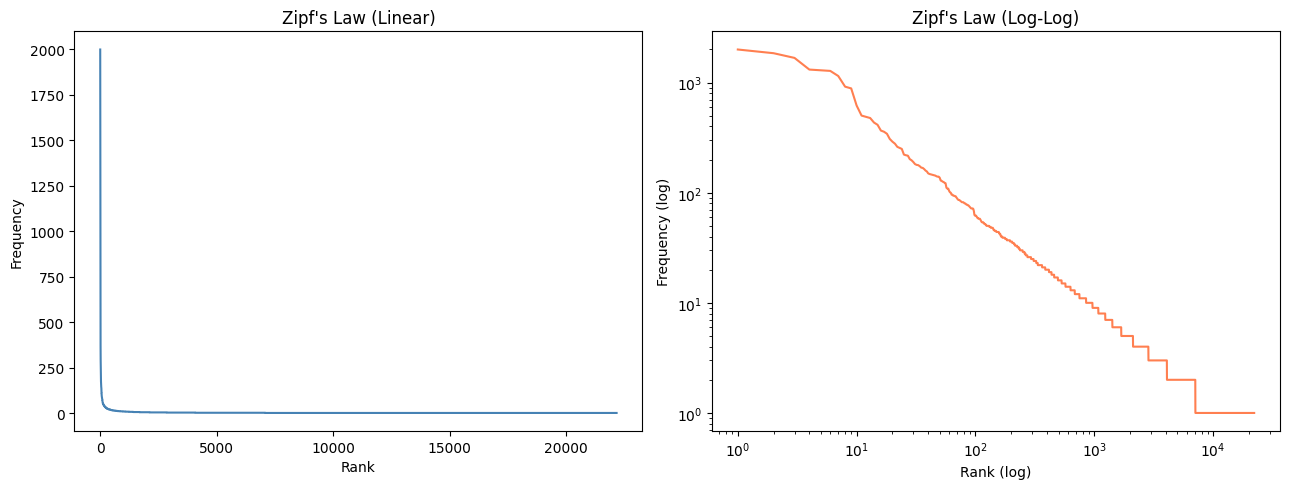

In [ ]:
freqs = sorted(vocab_freq.values(), reverse=True)
ranks = list(range(1, len(freqs) + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ranks, freqs, color='steelblue')
axes[0].set_title("Zipf's Law (Linear)")
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')

axes[1].loglog(ranks, freqs, color='coral')
axes[1].set_title("Zipf's Law (Log-Log)")
axes[1].set_xlabel('Rank (log)')
axes[1].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

In [ ]:
q_counts = qa_df['question'].value_counts()
print(f'Unique question templates: {len(q_counts)}')
print(f'Total questions: {len(qa_df)}')
print('\nTop 10 repeated question templates:')
for q, cnt in q_counts.head(10).items():
    print(f'  [{cnt}] {q}')

Unique question templates: 310
Total questions: 3890

Top 10 repeated question templates:
  [600] ماذا ورد في هذا الموضع من النص؟
  [600] ما الجملة المذكورة في هذا السياق؟
  [600] كيف صيغت العبارة هنا؟
  [600] ما الذي قيل في هذا الجزء؟
  [600] ما النص الحرفي المذكور في هذه الفقرة؟
  [60] كيف صيغت العبارة في النص؟
  [60] ما النص الحرفي المذكور هنا؟
  [60] ماذا ورد في النص حول هذه الجزئية؟
  [60] ما الجملة المذكورة في هذا الموضع؟
  [60] ما الذي قيل في هذا السياق؟


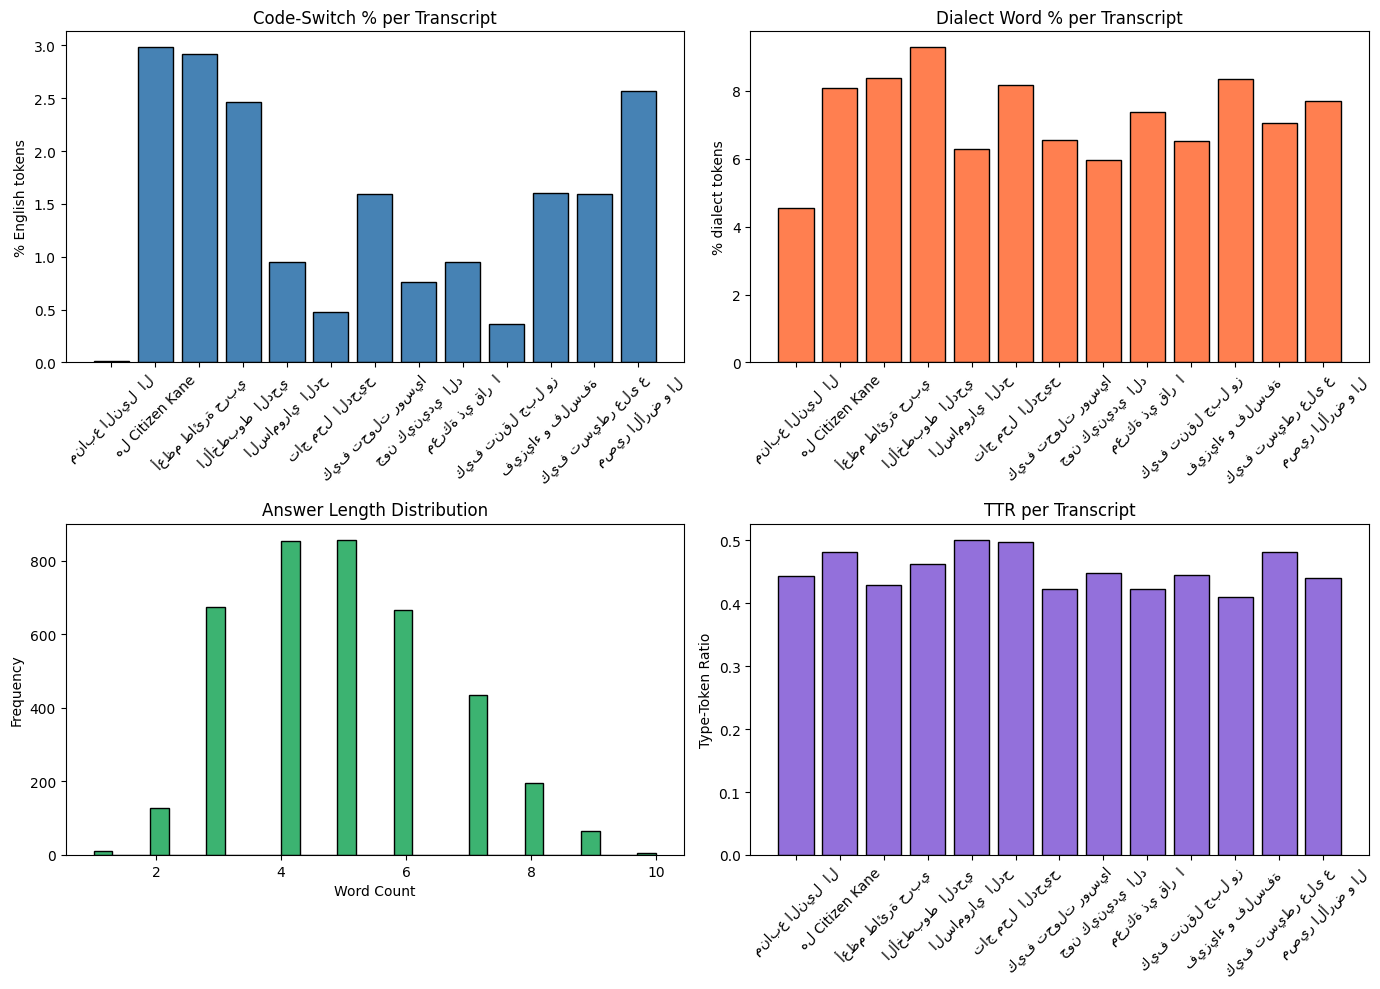

In [ ]:
# Compute per-transcript stats for plotting
per_stats = []
for title, text in transcripts.items():
    clean = TIMESTAMP_RE.sub('', text)
    tokens = ARABIC_WORD_RE.findall(clean)
    all_tok = clean.split()
    eng_count = sum(1 for t in all_tok if re.search(r'[A-Za-z]', t))
    dial_count = count_dialect(clean)
    unique_tok = set(tokens)
    ttr = len(unique_tok) / len(tokens) if tokens else 0
    per_stats.append({
        'title': title,
        'code_switch_pct': 100 * eng_count / len(all_tok) if all_tok else 0,
        'dialect_pct': 100 * dial_count / len(all_tok) if all_tok else 0,
        'ttr': ttr
    })

labels = [s['title'][:15] for s in per_stats]
code_switch = [s['code_switch_pct'] for s in per_stats]
dialect_pct = [s['dialect_pct'] for s in per_stats]
ttr_vals = [s['ttr'] for s in per_stats]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(labels, code_switch, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Code-Switch % per Transcript')
axes[0, 0].set_ylabel('% English tokens')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(labels, dialect_pct, color='coral', edgecolor='black')
axes[0, 1].set_title('Dialect Word % per Transcript')
axes[0, 1].set_ylabel('% dialect tokens')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].hist(qa_df['answer_len'], bins=30, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Answer Length Distribution')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].bar(labels, ttr_vals, color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('TTR per Transcript')
axes[1, 1].set_ylabel('Type-Token Ratio')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Text Normalization

The following 9 normalization steps are applied in order:

| Step | Description | Example |
|------|-------------|----------|
| 1 | Remove timestamps | `12.5: text` → `text` |
| 2 | Remove diacritics | `كَتَبَ` → `كتب` |
| 3 | Remove kashida (tatweel) | `جمـيـل` → `جميل` |
| 4 | Normalize alef variants (أإآٱ → ا) | `أحمد` → `احمد` |
| 5 | Spelling corrections (NORM_DICT) | `هاذا` → `هذا` |
| 6 | Normalize final letters (ى→ي, ؤ→و, ئ→ي, ة→ه) | `مدرسة` → `مدرسه` |
| 7 | Collapse repeated punctuation | `!!!` → `!` |
| 8 | Remove non-Arabic characters | `hello مرحبا` → `مرحبا` |
| 9 | Normalize whitespace | `كلمة  كلمة` → `كلمة كلمة` |

In [ ]:
NORM_DICT = {
    # Common spelling errors
    'هاذا': 'هذا',
    'هاذه': 'هذه',
    'هاذان': 'هذان',
    'هاذين': 'هذين',
    'كذالك': 'كذلك',
    'لاكن': 'لكن',
    # إن شاء الله variants
    'انشاء الله': 'إن شاء الله',
    'ان شاء الله': 'إن شاء الله',
    'انشالله': 'إن شاء الله',
    # مئة variants
    'مائة': 'مئة',
    'مائتين': 'مئتين',
    # Hamza corrections
    'فانه': 'فإنه',
    'بانه': 'بأنه',
    'لانه': 'لأنه',
    'لانها': 'لأنها',
    'لانهم': 'لأنهم',
}

# Sort by key length descending so longer patterns match first
NORM_DICT = dict(sorted(NORM_DICT.items(), key=lambda x: -len(x[0])))
print(f'NORM_DICT has {len(NORM_DICT)} entries (sorted by key length descending)')
for k, v in NORM_DICT.items():
    print(f'  {k} → {v}')

NORM_DICT has 16 entries (sorted by key length descending)
  ان شاء الله → إن شاء الله
  انشاء الله → إن شاء الله
  انشالله → إن شاء الله
  مائتين → مئتين
  هاذان → هذان
  هاذين → هذين
  كذالك → كذلك
  لانها → لأنها
  لانهم → لأنهم
  هاذا → هذا
  هاذه → هذه
  لاكن → لكن
  مائة → مئة
  فانه → فإنه
  بانه → بأنه
  لانه → لأنه


In [ ]:
def normalize_arabic(text):
    # Step 1: Remove timestamps
    text = re.sub(r"^\d+\.?\d*:\s*", "", text, flags=re.MULTILINE)
    # Step 2: Remove diacritics
    text = re.sub(r"[\u0617-\u061A\u064B-\u065F\u0670]", "", text)
    # Step 3: Remove kashida
    text = re.sub(r"\u0640+", "", text)
    # Step 4: Normalize alef variants to ا
    text = re.sub(r"[\u0623\u0625\u0622\u0671]", "\u0627", text)
    # Step 5: Apply spelling corrections
    for wrong, correct in NORM_DICT.items():
        text = text.replace(wrong, correct)
    # Step 6: Normalize final letters
    text = re.sub(r"\u0649", "\u064A", text)   # ى → ي
    text = re.sub(r"\u0624", "\u0648", text)   # ؤ → و
    #text = re.sub(r"\u0626", "\u064A", text)   # ئ → ي
    #text = re.sub(r"\u0629", "\u0647", text)   # ة → ه
    # Step 7: Collapse repeated punctuation
    text = re.sub(r"([!\u061F?.]){2,}", r"\1", text)
    # Step 8: Remove non-Arabic characters
    text = re.sub(r"[^\u0621-\u064A\s]", "", text)
    # Step 9: Normalize whitespace
    text = re.sub(r"[ \t]+", " ", text).strip()
    return text

# Demo
samples = [
    '12.5: هاذا الكِتَابُ جمـيـل جداً!!!',
    'لاكن ان شاء الله سنكمل بأنه مائة بالمائة',
    'أحمد وإبراهيم يدرسان في المدرسة'
]
print('Normalization Demo:')
print('-' * 60)
for s in samples:
    print(f'Before: {s}')
    print(f'After:  {normalize_arabic(s)}')
    print()

Normalization Demo:
------------------------------------------------------------
Before: 12.5: هاذا الكِتَابُ جمـيـل جداً!!!
After:  هذا الكتاب جميل جدا

Before: لاكن ان شاء الله سنكمل بأنه مائة بالمائة
After:  لكن إن شاء الله سنكمل بأنه مئة بالمئة

Before: أحمد وإبراهيم يدرسان في المدرسة
After:  احمد وابراهيم يدرسان في المدرسة



In [ ]:
# Vocab before normalization
raw_words = []
for text in transcripts.values():
    raw_words.extend(ARABIC_WORD_RE.findall(text))
vocab_before = Counter(raw_words)

# Vocab after normalization
norm_words = []
for text in transcripts.values():
    norm_text = normalize_arabic(text)
    norm_words.extend(ARABIC_WORD_RE.findall(norm_text))
vocab_after = Counter(norm_words)

reduction = 100 * (1 - len(vocab_after) / len(vocab_before))
print(f'Vocab size before normalization: {len(vocab_before)}')
print(f'Vocab size after normalization:  {len(vocab_after)}')
print(f'Reduction: {reduction:.1f}%')

# Add normalized columns to qa_df
qa_df['question_norm'] = qa_df['question'].astype(str).apply(normalize_arabic)
qa_df['answer_norm'] = qa_df['answer'].astype(str).apply(normalize_arabic)
print('\nAdded question_norm and answer_norm columns to qa_df')
qa_df[['question', 'question_norm', 'answer', 'answer_norm']].head(3)

Vocab size before normalization: 22164
Vocab size after normalization:  18623
Reduction: 16.0%

Added question_norm and answer_norm columns to qa_df


,question,question_norm,answer,answer_norm
0,ماذا ورد في النص حول هذه الجزئية؟,ماذا ورد في النص حول هذه الجزئية,والساموزين والسامو عليكم!,والساموزين والسامو عليكم
1,ما الجملة المذكورة في هذا الموضع؟,ما الجملة المذكورة في هذا الموضع,من كل مَن حرمه من حلم الساموراي...,من كل من حرمه من حلم الساموراي
2,كيف صيغت العبارة في النص؟,كيف صيغت العبارة في النص,السلام عليكم ورحمة الله وبركاته،,السلام عليكم ورحمة الله وبركاته


# Context Attachment

In [ ]:
def clean_title_for_lookup(title):
    return str(title).replace(' | الدحيح', '  الدحيح')

if 'video_title' in qa_df.columns:
    qa_df['cleaned_video_title'] = qa_df['video_title'].apply(clean_title_for_lookup)
elif 'title' in qa_df.columns:
    qa_df['cleaned_video_title'] = qa_df['title'].apply(clean_title_for_lookup)
else:
    str_cols = [c for c in qa_df.columns if qa_df[c].dtype == object]
    qa_df['cleaned_video_title'] = qa_df[str_cols[0]].apply(clean_title_for_lookup) if str_cols else ''

qa_df['context'] = qa_df['cleaned_video_title'].map(transcripts)
qa_df['context_clean'] = qa_df['context'].fillna('').astype(str).apply(normalize_arabic)

coverage = qa_df['context'].notna().sum()
print(f'Context coverage: {coverage}/{len(qa_df)} rows ({100*coverage/len(qa_df):.1f}%)')

Context coverage: 3890/3890 rows (100.0%)


# Data Preparation

Steps 5–6: Tokenization → Vocabulary → Token IDs → Padding

In [ ]:
qa_df['answer_tokens'] = qa_df['answer_norm'].astype(str).apply(str.split)
qa_df['context_tokens'] = qa_df['context_clean'].astype(str).apply(str.split)
print('Sample answer tokens:', qa_df['answer_tokens'].iloc[0][:10])
print('Sample context tokens:', qa_df['context_tokens'].iloc[0][:10])

Sample answer tokens: ['والساموزين', 'والسامو', 'عليكم']
Sample context tokens: ['منذ', 'زمن', 'بعيد', 'في', 'ارض', 'ليست', 'ببعيده', 'كان', 'هناك', 'طفل']


In [ ]:
all_prep_words = []
for tokens in qa_df['answer_norm'].astype(str).apply(str.split):
    all_prep_words.extend(tokens)
for tokens in qa_df['context_clean'].astype(str).apply(str.split):
    all_prep_words.extend(tokens)

word_freq = Counter(all_prep_words)
# Reserve 0 for padding, 1 for unknown
vocab_map = {word: idx + 2 for idx, (word, _) in enumerate(word_freq.most_common())}
vocab_map['<PAD>'] = 0
vocab_map['<UNK>'] = 1
print(f'Vocabulary size (vocab_map): {len(vocab_map)}')

Vocabulary size (vocab_map): 18323


In [ ]:
def to_ids(tokens):
    return [vocab_map.get(t, vocab_map['<UNK>']) for t in tokens]

qa_df['context_ids'] = qa_df['context_tokens'].apply(to_ids)
qa_df['answer_ids'] = qa_df['answer_tokens'].apply(to_ids)
print('Sample context_ids:', qa_df['context_ids'].iloc[0][:10])
print('Sample answer_ids:', qa_df['answer_ids'].iloc[0][:10])

Sample context_ids: [9342, 1376, 398, 2, 830, 976, 9343, 11, 85, 472]
Sample answer_ids: [6766, 6767, 479]


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

context_max_len = 7500
answer_max_len = 10

context_padded = pad_sequences(
    qa_df['context_ids'].tolist(),
    maxlen=context_max_len,
    padding='post',
    truncating='post',
    value=0
)

answer_padded = pad_sequences(
    qa_df['answer_ids'].tolist(),
    maxlen=answer_max_len,
    padding='post',
    truncating='post',
    value=0
)

print(f'context_padded shape: {context_padded.shape}')
print(f'answer_padded shape:  {answer_padded.shape}')

context_padded shape: (3890, 7500)
answer_padded shape:  (3890, 10)




##  Limitations and Future Work

Although the dataset has been cleaned and prepared for modeling, several challenges remain due to the nature of conversational Arabic transcripts.

**Long Context Length**
The transcripts can be long and may exceed the maximum input length of transformer models. In MS2, this can be addressed by splitting transcripts into smaller overlapping context chunks.

**Dialectal Variation**
The dataset contains both Modern Standard Arabic and Egyptian dialect expressions (e.g., *ليه*, *ازاي*, *كده*). These variations may affect tokenization and vocabulary consistency. Using pretrained Arabic models such as AraBERT can help handle this variability. In addition, we tried to make normalization not too aggressive, this may lead to more varriance.


**Code-Switching**
Some transcripts include English scientific terms within Arabic sentences, increasing vocabulary diversity. Multilingual tokenization can help manage these cases.

**Multiple Valid Answer Spans**
In narrative transcripts, the same information may appear multiple times, meaning a question can correspond to more than one valid answer span. This will need careful handling during model training.

---

### Final Dataset Preparation

After preprocessing, the dataset was structured into **(context, question, answer)** triplets suitable for extractive question answering models.

The preprocessing pipeline included:

* noise detection and cleaning (timestamps and formatting artifacts)
* Arabic text normalization
* tokenization and vocabulary construction
* text representation for machine learning models

This prepares the dataset for **neural QA architectures in Milestone 2** and **retrieval-based methods in Milestone 3**.
